In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from joblib import dump, load
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

df_scaled = pickle.load(open('data/df_scaled.pkl', 'rb'))
df_clean  = pickle.load(open('data/df_clean.pkl',  'rb'))
df_pca    = pickle.load(open('data/df_pca.pkl',    'rb'))
scaler    = pickle.load(open('data/scaler.pkl',    'rb'))
features  = pickle.load(open('data/features.pkl',  'rb'))

print('Data loaded. Shape:', df_scaled.shape)


Data loaded. Shape: (2224, 9)


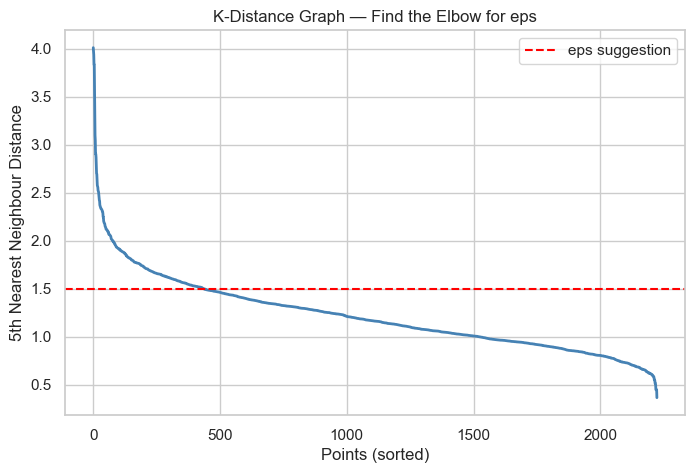

The elbow point = best eps value.


In [2]:
nbrs = NearestNeighbors(n_neighbors=5)
nbrs.fit(df_scaled)
distances, _ = nbrs.kneighbors(df_scaled)
kth_dist = np.sort(distances[:, 4])[::-1]

plt.figure(figsize=(8, 5))
plt.plot(kth_dist, linewidth=2, color='steelblue')
plt.xlabel('Points (sorted)')
plt.ylabel('5th Nearest Neighbour Distance')
plt.title('K-Distance Graph — Find the Elbow for eps')
plt.axhline(y=1.5, color='red', linestyle='--', label='eps suggestion')
plt.legend()
plt.savefig('data/dbscan_kdist.png', dpi=150, bbox_inches='tight')
plt.show()
print('The elbow point = best eps value.')


In [3]:
eps_values = [0.8, 1.0, 1.2, 1.5, 1.8, 2.0, 2.5]
print('Testing eps values...')
for eps in eps_values:
    db_test  = DBSCAN(eps=eps, min_samples=5)
    lbl_test = db_test.fit_predict(df_scaled)
    n_clust  = len(set(lbl_test)) - (1 if -1 in lbl_test else 0)
    n_noise  = list(lbl_test).count(-1)
    mask     = lbl_test != -1
    sil = silhouette_score(df_scaled[mask], lbl_test[mask]) if n_clust >= 2 and mask.sum() > 1 else -1
    print(f'  eps={eps}  clusters={n_clust}  noise={n_noise}  silhouette={sil:.4f}')
print('\nPick eps with best silhouette and 3-6 clusters.')


Testing eps values...
  eps=0.8  clusters=23  noise=1815  silhouette=0.0547
  eps=1.0  clusters=26  noise=1193  silhouette=-0.1460
  eps=1.2  clusters=20  noise=699  silhouette=-0.1387
  eps=1.5  clusters=5  noise=239  silhouette=-0.0962
  eps=1.8  clusters=1  noise=71  silhouette=-1.0000
  eps=2.0  clusters=1  noise=35  silhouette=-1.0000
  eps=2.5  clusters=1  noise=8  silhouette=-1.0000

Pick eps with best silhouette and 3-6 clusters.


In [4]:
EPS         = 1.5   # change based on tuning results
MIN_SAMPLES = 5

db        = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
db_labels = db.fit_predict(df_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = list(db_labels).count(-1)

print(f'DBSCAN trained (eps={EPS}, min_samples={MIN_SAMPLES})')
print(f'Clusters found: {n_clusters}')
print(f'Noise points  : {n_noise} ({n_noise/len(db_labels)*100:.1f}%)')
print('\nCluster sizes:')
unique, counts = np.unique(db_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {"Noise" if u == -1 else f"Cluster {u}"}: {c}')


DBSCAN trained (eps=1.5, min_samples=5)
Clusters found: 5
Noise points  : 239 (10.7%)

Cluster sizes:
  Noise: 239
  Cluster 0: 1968
  Cluster 1: 6
  Cluster 2: 5
  Cluster 3: 3
  Cluster 4: 3


In [5]:
mask = db_labels != -1
sil  = silhouette_score(df_scaled[mask], db_labels[mask]) if n_clusters >= 2 else -1
dbs  = davies_bouldin_score(df_scaled[mask], db_labels[mask]) if n_clusters >= 2 else -1

print('=== DBSCAN Evaluation Metrics ===')
print(f'eps                 : {EPS}')
print(f'min_samples         : {MIN_SAMPLES}')
print(f'Clusters found      : {n_clusters}')
print(f'Noise points        : {n_noise}')
print(f'Silhouette Score    : {sil:.4f}  (higher = better)')
print(f'Davies-Bouldin Score: {dbs:.4f}  (lower  = better)')

scores = {'algorithm': 'DBSCAN', 'n_clusters': n_clusters,
          'silhouette': round(sil, 4), 'davies_bouldin': round(dbs, 4),
          'inertia': 'N/A', 'noise': n_noise}
pickle.dump(scores,    open('data/dbscan_scores.pkl', 'wb'))
pickle.dump(db_labels, open('data/dbscan_labels.pkl', 'wb'))


=== DBSCAN Evaluation Metrics ===
eps                 : 1.5
min_samples         : 5
Clusters found      : 5
Noise points        : 239
Silhouette Score    : -0.0962  (higher = better)
Davies-Bouldin Score: 1.1629  (lower  = better)


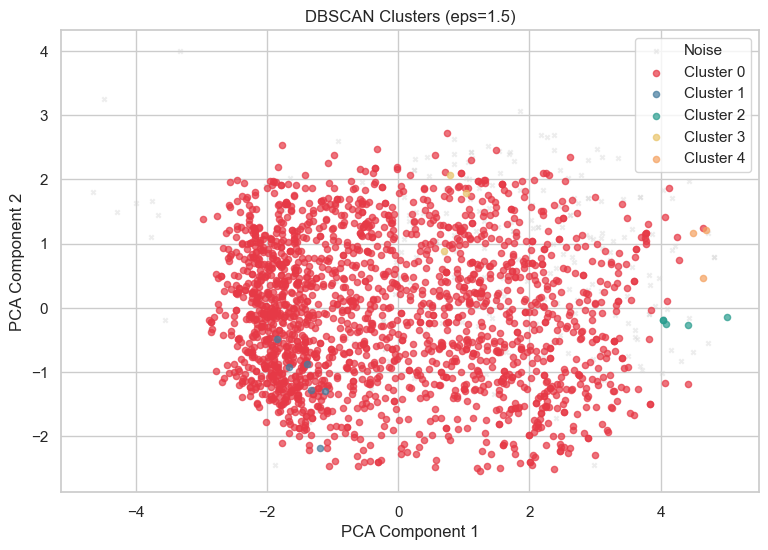

In [6]:
colors = ['#E63946','#457B9D','#2A9D8F','#E9C46A','#F4A261','#264653','#7B2D8B']

plt.figure(figsize=(9, 6))
for label in sorted(set(db_labels)):
    mask = db_labels == label
    if label == -1:
        plt.scatter(df_pca[mask, 0], df_pca[mask, 1],
                    s=10, c='lightgray', marker='x', label='Noise', alpha=0.4)
    else:
        plt.scatter(df_pca[mask, 0], df_pca[mask, 1],
                    s=20, color=colors[label % len(colors)],
                    label=f'Cluster {label}', alpha=0.7)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'DBSCAN Clusters (eps={EPS})')
plt.legend()
plt.savefig('data/dbscan_pca.png', dpi=150, bbox_inches='tight')
plt.show()


=== Cluster Profiles (excluding noise) ===
           Age    Income  TotalSpend  TotalPurchases  TotalChildren  Recency  \
Cluster                                                                        
0        54.92  50148.92      539.17           14.22           0.99    48.93   
1        71.50  18131.17       34.33            5.00           0.00    22.33   
2        50.60  84995.80     2067.80           20.00           0.00    49.00   
3        51.00  49948.67      997.33           24.33           0.00    74.33   
4        46.67  90839.33     2107.00           24.00           0.00    76.67   

         Days_Customer  TotalAccepted  NumWebVisitsMonth  
Cluster                                                   
0              3820.90           0.28               5.32  
1              3691.83           0.00               5.17  
2              3661.60           4.00               1.60  
3              4101.67           0.00               7.00  
4              3891.33           4.00     

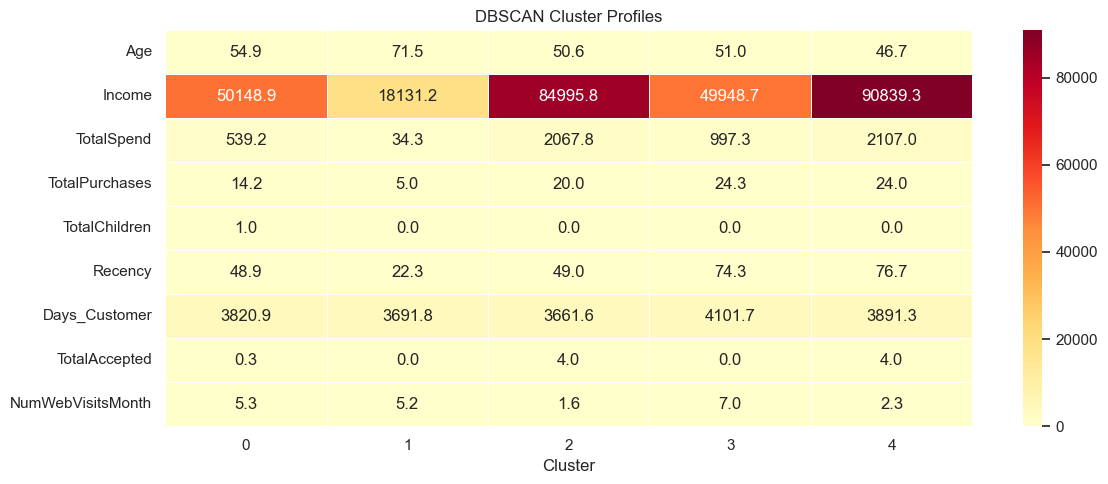

In [7]:
# Cluster profiles
df_result = df_clean.copy()
df_result['Cluster'] = db_labels
profile = df_result[df_result['Cluster'] != -1].groupby('Cluster').mean().round(2)
print('=== Cluster Profiles (excluding noise) ===')
print(profile)

plt.figure(figsize=(12, 5))
sns.heatmap(profile.T, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('DBSCAN Cluster Profiles')
plt.tight_layout()
plt.savefig('data/dbscan_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
from joblib import dump

# Save DBSCAN model
dump(db, 'data/dbscan_model.joblib')

# Also save training data + labels (needed for predicting new points)
pickle.dump({'X_train': df_scaled, 'labels': db_labels},
            open('data/dbscan_train_data.pkl', 'wb'))

print('Saved: data/dbscan_model.joblib')
print('Saved: data/dbscan_train_data.pkl')
print(f'  eps         : {EPS}')
print(f'  min_samples : {MIN_SAMPLES}')
print(f'  Clusters    : {n_clusters}')


Saved: data/dbscan_model.joblib
Saved: data/dbscan_train_data.pkl
  eps         : 1.5
  min_samples : 5
  Clusters    : 5


In [9]:
from sklearn.neighbors import NearestNeighbors

# Load saved data
train_data    = pickle.load(open('data/dbscan_train_data.pkl', 'rb'))
X_train       = train_data['X_train']
train_labels  = train_data['labels']

# Define cluster descriptions (update after seeing your profiles!)
cluster_labels = {
    0: 'High Income, High Spender (VIP)',
    1: 'Low Income, Low Spender (Budget)',
    2: 'Medium Income, Regular Buyer',
   -1: 'Outlier / Unusual Customer'
}

print('Ready to predict new customer cluster.')


Ready to predict new customer cluster.


In [10]:
print('=== Enter New Customer Details ===')

age             = float(input('Enter Age: '))
income          = float(input('Enter Annual Income: '))
total_spend     = float(input('Enter Total Spend: '))
total_purchases = float(input('Enter Total Purchases: '))
total_children  = float(input('Enter Total Children: '))
recency         = float(input('Enter Recency (days since last purchase): '))
days_customer   = float(input('Enter Days as Customer: '))
total_accepted  = float(input('Enter Total Campaigns Accepted (0-6): '))
web_visits      = float(input('Enter Web Visits per Month: '))

new_customer        = np.array([[age, income, total_spend, total_purchases,
                                  total_children, recency, days_customer,
                                  total_accepted, web_visits]])
new_customer_scaled = scaler.transform(new_customer)

# Find nearest neighbour in training data
nn = NearestNeighbors(n_neighbors=1)
nn.fit(X_train)
_, indices       = nn.kneighbors(new_customer_scaled)
nearest_label    = train_labels[indices[0][0]]

print(f'\n=== Prediction Result ===')
print(f'Nearest cluster     : {nearest_label}')
print(f'Cluster Description : {cluster_labels.get(nearest_label, "Unknown")}')
if nearest_label == -1:
    print('Note: This customer is unusual and does not fit any existing cluster.')


=== Enter New Customer Details ===


Enter Age:  18
Enter Annual Income:  36000
Enter Total Spend:  1000
Enter Total Purchases:  5
Enter Total Children:  0
Enter Recency (days since last purchase):  365
Enter Days as Customer:  2
Enter Total Campaigns Accepted (0-6):  5
Enter Web Visits per Month:  5



=== Prediction Result ===
Nearest cluster     : -1
Cluster Description : Outlier / Unusual Customer
Note: This customer is unusual and does not fit any existing cluster.
